# Headline

In [1]:
"""
from google.colab import drive
drive.mount('/content/drive')
"""

"\nfrom google.colab import drive\ndrive.mount('/content/drive')\n"

## Download

## Import

In [17]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions.categorical import Categorical

import matplotlib.pyplot as plt
from torch.distributions.normal import Normal

import yfinance as yf
import torch.nn.functional as F

# Input

In [3]:
def get_real_market_data(ticker: str = "BTC-USD", start: str = "2020-01-01", end: str = "2024-01-01"):
    # Tải dữ liệu OHLCV
    raw_df = yf.download(ticker, start=start, end=end, progress=False)

    # Xử lý MultiIndex columns nếu yfinance trả về dạng MultiIndex
    if isinstance(raw_df.columns, pd.MultiIndex):
        raw_df.columns = raw_df.columns.get_level_values(0)

    df = pd.DataFrame(index=raw_df.index)
    df["close"] = raw_df["Close"].astype(float)

    # 1. Stationary Feature: Log Return
    df["log_ret"] = np.log(df["close"] / df["close"].shift(1))

    # 2. Volatility Feature: Rolling 20-day annualized vol
    df["volatility"] = df["log_ret"].rolling(window=20).std() * np.sqrt(252)

    # 3. Momentum Feature: RSI 14 normalized về [-1, 1]
    delta = df["close"].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / (loss + 1e-8)
    rsi = 100 - (100 / (1 + rs))
    df["rsi_norm"] = (rsi - 50.0) / 50.0  # Scale từ [0, 100] -> [-1, 1]

    # 4. Trend Feature: Normalized MACD
    ema12 = df["close"].ewm(span=12, adjust=False).mean()
    ema26 = df["close"].ewm(span=26, adjust=False).mean()
    macd = (ema12 - ema26) / df["close"]  # Scale theo tỷ lệ phần trăm giá
    df["macd_norm"] = macd

    # 5. Volume Change
    df["vol_change"] = np.log(raw_df["Volume"].astype(float) + 1).diff()

    # Loại bỏ các hàng NaN do rolling window
    df = df.dropna().reset_index(drop=True)
    return df

# Lấy dữ liệu Bitcoin
df_market = get_real_market_data("BTC-USD", start="2020-01-01", end="2024-01-01")
print(f"Tổng số nến hợp lệ: {len(df_market)}")

/tmp/ipykernel_60553/3450985143.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  raw_df = yf.download(ticker, start=start, end=end, progress=False)


Tổng số nến hợp lệ: 1441


## Train-Test Split

In [4]:
# Train: ~70% (khoảng 2020 đến giữa 2022 - gồm cả đỉnh bull và downtrend sâu)
# Test:  ~30% (từ giữa 2022 đến cuối 2023 - đoạn phục hồi và sideway gập ghềnh)
split_idx = int(len(df_market) * 0.7)

train_df = df_market.iloc[:split_idx].copy().reset_index(drop=True)
test_df = df_market.iloc[split_idx:].copy().reset_index(drop=True)

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)}")

Train samples: 1008 | Test samples: 433


# Setup

## Environment

In [5]:
class TimeSeriesTradingEnv(gym.Env):
    """
    Custom Gym Environment Discrete với cơ chế Hard Trend-Shield:
      - Khi thị trường Uptrend (Close > EMA50): Cấm Short (nếu Agent chọn Short, tự động chuyển về Cash).
      - Khi thị trường Downtrend (Close < EMA50): Cấm Long (nếu Agent chọn Long, tự động chuyển về Cash).
      - Reward = Log Return thực tế sau khi trừ phí giao dịch (không dùng phạt biến động nhân tạo).
    """
    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        df: pd.DataFrame,
        window_size: int = 10,
        transaction_fee: float = 0.0002,     # 0.02% phí turnover
        initial_balance: float = 10000.0,
    ):
        super().__init__()

        self.df = df.reset_index(drop=True)
        self.window_size = window_size
        self.fee = transaction_fee
        self.initial_balance = initial_balance

        assert "close" in self.df.columns, "DataFrame cần có cột 'close'."
        self.feature_cols = [c for c in self.df.columns if c != "close"]
        self.num_features = len(self.df.columns)

        # 0: Cash, 1: Long, 2: Short
        self.action_space = spaces.Discrete(3)

        # [window_size * num_features] + 1 feature vị thế
        obs_dim = (self.window_size * self.num_features) + 1
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

        self.current_step = 0
        self.current_position = 0  # -1: Short, 0: Cash, 1: Long
        self.balance = self.initial_balance

    def _get_observation(self) -> np.ndarray:
        start = self.current_step - self.window_size
        end = self.current_step
        window_data = self.df.iloc[start:end].values.astype(np.float32)

        flat_features = window_data.flatten()
        obs = np.append(flat_features, np.float32(self.current_position))
        return obs

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.current_step = self.window_size
        self.current_position = 0
        self.balance = self.initial_balance

        observation = self._get_observation()
        info = {
            "balance": self.balance,
            "position": self.current_position,
            "step": self.current_step,
        }

        return observation, info

    def step(self, action: int):
        target_pos_map = {0: 0, 1: 1, 2: -1}
        desired_position = target_pos_map[action]

        # Kiểm tra chế độ xu hướng dựa trên EMA50
        trend_val = self.df.loc[self.current_step, "trend_ema50"] if "trend_ema50" in self.df.columns else 0.0

        # HARD TREND-SHIELD: Khóa các hành vi ngược sóng vĩ mô
        if trend_val > 0.0 and desired_position == -1:
            target_position = 0  # Đang uptrend mà chọn Short -> Ép về giữ Cash
        elif trend_val < -0.05 and desired_position == 1:
            target_position = 0  # Đang downtrend sâu mà chọn Long -> Ép về giữ Cash
        else:
            target_position = desired_position

        current_price = self.df.loc[self.current_step, "close"]
        next_price = self.df.loc[self.current_step + 1, "close"]

        asset_return = (next_price - current_price) / current_price

        # Chi phí turnover
        turnover = abs(target_position - self.current_position)
        trade_cost = turnover * self.fee

        step_return = (target_position * asset_return) - trade_cost

        prev_balance = self.balance
        self.balance *= (1.0 + step_return)
        self.current_position = target_position
        self.current_step += 1

        # Reward = Log Return thuần túy của danh mục
        safe_ratio = max(1e-6, self.balance / prev_balance)
        reward = float(np.log(safe_ratio))

        terminated = self.current_step >= len(self.df) - 1
        truncated = self.balance <= (self.initial_balance * 0.2)

        if terminated and self.current_position != 0:
            closing_cost = abs(0 - self.current_position) * self.fee
            self.balance *= (1.0 - closing_cost)
            self.current_position = 0

        observation = self._get_observation()
        info = {
            "step": self.current_step,
            "price": next_price,
            "balance": self.balance,
            "position": self.current_position,
        }

        return observation, reward, terminated, truncated, info

## Cấu trúc Actor-Critic Network (PyTorch)

In [6]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int = 3, hidden_dim: int = 64):
        super().__init__()

        self.shared_net = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
        )

        self.actor = nn.Linear(hidden_dim, action_dim)
        self.critic = nn.Linear(hidden_dim, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, gain=np.sqrt(2))
                nn.init.constant_(m.bias, 0.0)
        nn.init.orthogonal_(self.actor.weight, gain=0.01)
        nn.init.orthogonal_(self.critic.weight, gain=1.0)

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.shared_net(x)
        return self.critic(feat).squeeze(-1)

    def get_action_and_value(self, x: torch.Tensor, action: torch.Tensor = None):
        feat = self.shared_net(x)
        logits = self.actor(feat)
        dist = Categorical(logits=logits)

        if action is None:
            action = dist.sample()

        return (
            action,
            dist.log_prob(action),
            dist.entropy(),
            self.critic(feat).squeeze(-1),
        )

## Pipeline Huấn luyện và Đánh giá

In [7]:
# ==========================================
# 1. HÀM TÍNH METRICS HIỆU SUẤT DANH MỤC
# ==========================================
def calculate_portfolio_metrics(balance_history: list, risk_free_rate: float = 0.0, periods_per_year: int = 252):
    """
    Tính toán các chỉ số rủi ro và hiệu suất danh mục tài chính từ equity curve.
    """
    balances = np.array(balance_history)
    step_returns = np.diff(balances) / balances[:-1]

    # Cumulative Return
    total_return = (balances[-1] - balances[0]) / balances[0]

    # Annualized Return & Volatility
    n_steps = len(step_returns)
    if n_steps == 0:
        return {}

    ann_return = np.mean(step_returns) * periods_per_year
    ann_vol = np.std(step_returns) * np.sqrt(periods_per_year)

    # Sharpe Ratio
    excess_return = ann_return - risk_free_rate
    sharpe = excess_return / (ann_vol + 1e-8) if ann_vol > 0 else 0.0

    # Maximum Drawdown (MDD)
    cum_max = np.maximum.accumulate(balances)
    drawdowns = (balances - cum_max) / cum_max
    max_drawdown = np.min(drawdowns)

    # Win Rate (% số bước có lợi nhuận dương)
    win_trades = step_returns[step_returns != 0]
    win_rate = np.mean(win_trades > 0) if len(win_trades) > 0 else 0.0

    return {
        "Total Return": total_return,
        "Annualized Return": ann_return,
        "Annualized Vol": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_drawdown,
        "Win Rate": win_rate
    }

# ==========================================
# HÀM TÍNH GENERALIZED ADVANTAGE ESTIMATION (GAE)
# ==========================================
def compute_gae(rewards, values, dones, next_value, next_done, gamma, gae_lambda):
    advantages = torch.zeros_like(rewards)
    last_gae_lam = 0
    # Reverse loop để tính GAE
    for t in reversed(range(len(rewards))):
        if t == len(rewards) - 1:
            next_non_terminal = 1.0 - next_done
            next_values = next_value
        else:
            next_non_terminal = 1.0 - dones[t + 1]
            next_values = values[t + 1]

        delta = rewards[t] + gamma * next_values * next_non_terminal - values[t]
        advantages[t] = last_gae_lam = delta + gamma * gae_lambda * next_non_terminal * last_gae_lam

    returns = advantages + values
    return advantages, returns


# ==========================================
# 2. VÒNG LẶP HUẤN LUYỆN ĐẦU-CUỐI (TRAIN LOOP)
# ==========================================
def train_agent(
    env,
    model,
    algorithm: str = "PPO",
    total_timesteps: int = 40000,
    rollout_len: int = 64,
    lr: float = 3e-4,
    gamma: float = 0.99,
    gae_lambda: float = 0.95,
    c1: float = 0.5,
    c2: float = 0.05,
    ppo_epochs: int = 4,
    ppo_batch_size: int = 32,
    clip_eps: float = 0.2,
):
    optimizer = optim.Adam(model.parameters(), lr=lr, eps=1e-5)
    obs_dim = env.observation_space.shape[0]

    obs, _ = env.reset()
    obs_tensor = torch.tensor(obs, dtype=torch.float32)
    done = False

    num_updates = total_timesteps // rollout_len
    print(f"--- Bắt đầu huấn luyện {algorithm} | Tổng Updates: {num_updates} ---")

    for update in range(1, num_updates + 1):
        obs_b = torch.zeros((rollout_len, obs_dim))
        actions_b = torch.zeros(rollout_len, dtype=torch.long)
        logprobs_b = torch.zeros(rollout_len)
        rewards_b = torch.zeros(rollout_len)
        dones_b = torch.zeros(rollout_len)
        values_b = torch.zeros(rollout_len)

        for step in range(rollout_len):
            obs_b[step] = obs_tensor
            dones_b[step] = float(done)

            with torch.no_grad():
                action, log_prob, _, val = model.get_action_and_value(
                    obs_tensor.unsqueeze(0)
                )

            actions_b[step] = action.squeeze()
            logprobs_b[step] = log_prob.squeeze()
            values_b[step] = val.squeeze()

            next_obs, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            rewards_b[step] = float(reward)
            obs_tensor = torch.tensor(next_obs, dtype=torch.float32)

            if done:
                obs, _ = env.reset()
                obs_tensor = torch.tensor(obs, dtype=torch.float32)

        with torch.no_grad():
            next_value = model.get_value(obs_tensor.unsqueeze(0)).squeeze()

        advantages_b, returns_b = compute_gae(
            rewards_b,
            values_b,
            dones_b,
            next_value,
            torch.tensor(float(done)),
            gamma,
            gae_lambda,
        )

        if algorithm.upper() == "A2C":
            norm_adv = (advantages_b - advantages_b.mean()) / (
                advantages_b.std() + 1e-8
            )
            _, new_logprobs, entropy, new_vals = model.get_action_and_value(
                obs_b, actions_b
            )

            policy_loss = -(new_logprobs * norm_adv).mean()
            value_loss = 0.5 * ((new_vals - returns_b) ** 2).mean()
            entropy_loss = entropy.mean()
            loss = policy_loss + (c1 * value_loss) - (c2 * entropy_loss)

            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()

        elif algorithm.upper() == "PPO":
            for _ in range(ppo_epochs):
                permutation = torch.randperm(rollout_len)
                for start in range(0, rollout_len, ppo_batch_size):
                    batch_idx = permutation[start : start + ppo_batch_size]

                    _, new_logprob, entropy, new_val = model.get_action_and_value(
                        obs_b[batch_idx], actions_b[batch_idx]
                    )

                    batch_adv = advantages_b[batch_idx]
                    batch_adv = (batch_adv - batch_adv.mean()) / (
                        batch_adv.std() + 1e-8
                    )

                    ratio = torch.exp(new_logprob - logprobs_b[batch_idx])
                    surr1 = ratio * batch_adv
                    surr2 = torch.clamp(ratio, 1.0 - clip_eps, 1.0 + clip_eps) * batch_adv
                    policy_loss = -torch.min(surr1, surr2).mean()

                    value_loss = 0.5 * ((new_val - returns_b[batch_idx]) ** 2).mean()
                    entropy_loss = entropy.mean()
                    loss = policy_loss + (c1 * value_loss) - (c2 * entropy_loss)

                    optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                    optimizer.step()

        if update % (max(1, num_updates // 5)) == 0:
            print(
                f"Update {update:3d}/{num_updates} | Mean Step Reward: {rewards_b.mean():.6f}"
            )

    print("--- Huấn luyện hoàn tất ---")
    return model

# ==========================================
# 3. BACKTEST OUT-OF-SAMPLE / EVALUATION
# ==========================================
def evaluate_strategy(
    env,
    model
):
    """
    Chạy 1 episode evaluation từ đầu đến cuối tập dữ liệu (deterministic policy).
    """
    model.eval()
    obs, info = env.reset()
    balances = [info["balance"]]
    positions = [info["position"]]
    actions_taken = []

    done = False
    while not done:
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            feat = model.shared_net(obs_tensor)
            logits = model.actor(feat)
            action = torch.argmax(logits, dim=-1).item()  # Chọn Greedy Action khi test

        obs, _, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        balances.append(info["balance"])
        positions.append(info["position"])
        actions_taken.append(action)

    metrics = calculate_portfolio_metrics(balances)
    return metrics, balances, positions

# Training Loop

## Environment Establish

In [8]:
# 1. Tạo môi trường discrete tích hợp Trend Shield
train_env = TimeSeriesTradingEnv(df=train_df, window_size=10, transaction_fee=0.0002)
test_env = TimeSeriesTradingEnv(df=test_df, window_size=10, transaction_fee=0.0002)

obs_dim = train_env.observation_space.shape[0]
print(f"Feature Dimension (Observation Space): {obs_dim}")

Feature Dimension (Observation Space): 61


## Agent Define

In [9]:
# 2. Khởi tạo mạng ActorCritic Discrete
ppo_agent = ActorCritic(obs_dim=obs_dim, action_dim=3)
trained_ppo = train_agent(train_env, ppo_agent, algorithm="PPO", total_timesteps=40000, rollout_len=64)

a2c_agent = ActorCritic(obs_dim=obs_dim, action_dim=3)
trained_a2c = train_agent(train_env, a2c_agent, algorithm="A2C", total_timesteps=40000, rollout_len=64)

--- Bắt đầu huấn luyện PPO | Tổng Updates: 625 ---
Update 125/625 | Mean Step Reward: -0.007866
Update 250/625 | Mean Step Reward: 0.007324
Update 375/625 | Mean Step Reward: -0.000671
Update 500/625 | Mean Step Reward: 0.000669
Update 625/625 | Mean Step Reward: 0.002710
--- Huấn luyện hoàn tất ---
--- Bắt đầu huấn luyện A2C | Tổng Updates: 625 ---
Update 125/625 | Mean Step Reward: -0.001918
Update 250/625 | Mean Step Reward: 0.003550
Update 375/625 | Mean Step Reward: -0.000381
Update 500/625 | Mean Step Reward: -0.000150
Update 625/625 | Mean Step Reward: 0.001710
--- Huấn luyện hoàn tất ---


# Validation pipeline

## Trajectory & Metrics


=== KẾT QUẢ ĐÁNH GIÁ CHIẾN LƯỢC CÓ TREND-SHIELD ===
|                |   Total Return |   Annualized Return |   Annualized Vol |   Sharpe Ratio |   Max Drawdown |   Win Rate |
|:---------------|---------------:|--------------------:|-----------------:|---------------:|---------------:|-----------:|
| PPO (Shielded) |         0.3233 |              0.1984 |           0.2511 |         0.7901 |        -0.3391 |     0.3158 |
| A2C (Shielded) |         0.5594 |              0.3236 |           0.3412 |         0.9485 |        -0.3041 |     0.362  |
| Buy & Hold     |         0.9986 |              0.4881 |           0.3859 |         1.2649 |        -0.2582 |     0.4882 |


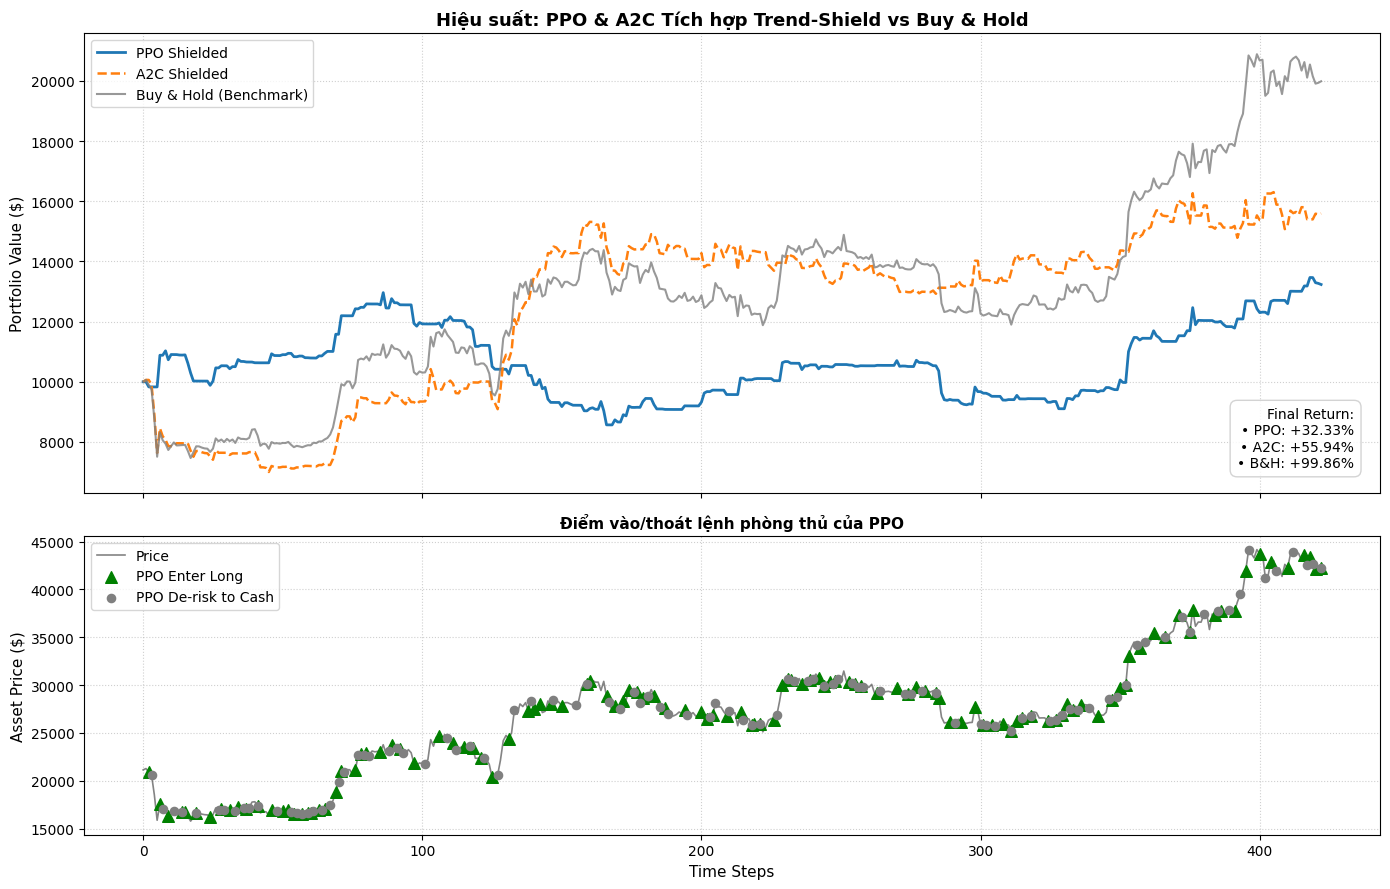


--- Phân phối Hành động Thực thi ---
PPO Positions: {0: 219, 1: 168, -1: 36}
A2C Positions: {1: 248, 0: 121, -1: 54}


In [12]:
# ===========================================================================
# 1. HÀM ĐÁNH GIÁ ĐỒNG BỘ TRAJECTORY & METRICS CHO CONTINUOUS PPO
# ===========================================================================
def evaluate_continuous_and_record(
    env,
    model,
    mode: str = "deterministic"
):
    """
    Đánh giá mô hình Continuous PPO và ghi nhận toàn bộ trajectory cùng metrics.
    mode:
      - 'deterministic': Dùng sigmoid(mean) để ra quyết định tỷ trọng tối ưu.
      - 'sample': Lấy mẫu từ phân phối Gaussian squashed qua sigmoid.
    """
    model.eval()
    obs, info = env.reset()

    balances = [info["balance"]]
    weights = [info["weight"]]
    prices = [env.df.loc[env.current_step, "close"]]
    actions_taken = [info["weight"]]

    done = False
    while not done:
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            if mode == "deterministic":
                feat = model.shared_net(obs_tensor)
                mean = model.actor_mean(feat)
                action = torch.sigmoid(mean).cpu().numpy()[0]
            else:
                action_tensor, _, _, _ = model.get_action_and_value(obs_tensor)
                action = action_tensor.cpu().numpy()[0]

        obs, _, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        balances.append(info["balance"])
        weights.append(info["weight"])
        prices.append(info["price"])
        actions_taken.append(float(action[0]))

    metrics = calculate_portfolio_metrics(balances)

    return {
        "balances": np.array(balances),
        "weights": np.array(weights),
        "actions": np.array(actions_taken),
        "prices": np.array(prices),
        "metrics": metrics,
    }


# ===========================================================================
# 2. HÀM TRỰC QUAN HÓA VÀ SO SÁNH HIỆU SUẤT CONTINUOUS PPO VS BENCHMARK
# ===========================================================================
def evaluate_and_record_discrete(env, model, mode: str = "sample", temperature: float = 0.7):
    model.eval()
    obs, info = env.reset()

    balances = [info["balance"]]
    positions = [info["position"]]
    prices = [env.df.loc[env.current_step, "close"]]
    actions = [0]

    done = False
    while not done:
        obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            feat = model.shared_net(obs_tensor)
            logits = model.actor(feat)

            if mode == "argmax":
                action_idx = torch.argmax(logits, dim=-1).item()
            else:
                scaled_logits = logits / max(1e-4, temperature)
                dist = Categorical(logits=scaled_logits)
                action_idx = dist.sample().item()

        obs, _, terminated, truncated, info = env.step(action_idx)
        done = terminated or truncated

        balances.append(info["balance"])
        positions.append(info["position"])
        prices.append(info["price"])
        actions.append(action_idx)

    metrics = calculate_portfolio_metrics(balances)

    return {
        "balances": np.array(balances),
        "positions": np.array(positions),
        "actions": np.array(actions),
        "prices": np.array(prices),
        "metrics": metrics,
    }


def plot_shielded_strategy(test_env, trained_ppo, trained_a2c, initial_capital=10000.0):
    ppo_res = evaluate_and_record_discrete(test_env, trained_ppo, mode="sample", temperature=0.7)
    a2c_res = evaluate_and_record_discrete(test_env, trained_a2c, mode="sample", temperature=0.7)

    prices = ppo_res["prices"]
    steps = np.arange(len(prices))

    buy_and_hold = initial_capital * (prices / prices[0])
    bnh_metrics = calculate_portfolio_metrics(buy_and_hold.tolist())

    df_eval = pd.DataFrame(
        [ppo_res["metrics"], a2c_res["metrics"], bnh_metrics],
        index=["PPO (Shielded)", "A2C (Shielded)", "Buy & Hold"]
    )
    print("\n=== KẾT QUẢ ĐÁNH GIÁ CHIẾN LƯỢC CÓ TREND-SHIELD ===")
    print(df_eval.map(lambda x: f"{x:.4f}").to_markdown())

    fig, (ax_equity, ax_actions) = plt.subplots(
        2, 1, figsize=(14, 9), sharex=True, gridspec_kw={"height_ratios": [2, 1.3]}
    )
    plt.subplots_adjust(hspace=0.08)

    ax_equity.plot(steps, ppo_res["balances"], label="PPO Shielded", color="#1f77b4", linewidth=2.0)
    ax_equity.plot(steps, a2c_res["balances"], label="A2C Shielded", color="#ff7f0e", linewidth=1.8, linestyle="--")
    ax_equity.plot(steps, buy_and_hold, label="Buy & Hold (Benchmark)", color="#7f7f7f", linewidth=1.5, alpha=0.8)

    ax_equity.set_title("Hiệu suất: PPO & A2C Tích hợp Trend-Shield vs Buy & Hold", fontsize=13, fontweight="bold")
    ax_equity.set_ylabel("Portfolio Value ($)", fontsize=11)
    ax_equity.grid(True, linestyle=":", alpha=0.6)
    ax_equity.legend(loc="upper left")

    ppo_ret = (ppo_res["balances"][-1] / initial_capital - 1) * 100
    a2c_ret = (a2c_res["balances"][-1] / initial_capital - 1) * 100
    bnh_ret = (buy_and_hold[-1] / initial_capital - 1) * 100

    textstr = f"Final Return:\n• PPO: {ppo_ret:+.2f}%\n• A2C: {a2c_ret:+.2f}%\n• B&H: {bnh_ret:+.2f}%"
    ax_equity.text(0.98, 0.05, textstr, transform=ax_equity.transAxes, fontsize=10,
                   verticalalignment="bottom", horizontalalignment="right",
                   bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="#ccc"))

    ax_actions.plot(steps, prices, color="#333333", alpha=0.6, label="Price", linewidth=1.2)
    pos_diff = np.diff(ppo_res["positions"], prepend=0)
    long_idx = np.where(pos_diff > 0)[0]
    flat_idx = np.where((ppo_res["positions"] == 0) & (pos_diff != 0))[0]

    if len(long_idx) > 0:
        ax_actions.scatter(steps[long_idx], prices[long_idx], marker="^", color="green", s=70, label="PPO Enter Long", zorder=5)
    if len(flat_idx) > 0:
        ax_actions.scatter(steps[flat_idx], prices[flat_idx], marker="o", color="gray", s=35, label="PPO De-risk to Cash", zorder=5)

    ax_actions.set_title("Điểm vào/thoát lệnh phòng thủ của PPO", fontsize=11, fontweight="bold")
    ax_actions.set_xlabel("Time Steps", fontsize=11)
    ax_actions.set_ylabel("Asset Price ($)", fontsize=11)
    ax_actions.grid(True, linestyle=":", alpha=0.6)
    ax_actions.legend(loc="upper left")

    plt.tight_layout()
    plt.show()

    print("\n--- Phân phối Hành động Thực thi ---")
    print("PPO Positions:", pd.Series(ppo_res["positions"]).value_counts().to_dict())
    print("A2C Positions:", pd.Series(a2c_res["positions"]).value_counts().to_dict())


# Đánh giá và vẽ biểu đồ phân bổ tỷ trọng liên tục của Continuous PPO
plot_shielded_strategy(test_env, trained_ppo, trained_a2c)

## Monte Carlo Evaluation

--- Bắt đầu chạy Monte Carlo (50 lần thử nghiệm | Temp: 0.7) ---
Hoàn tất mô phỏng: 10/50
Hoàn tất mô phỏng: 20/50
Hoàn tất mô phỏng: 30/50
Hoàn tất mô phỏng: 40/50
Hoàn tất mô phỏng: 50/50

=== BÁO CÁO PHÂN TÍCH ĐỘ BỀN VỮNG MONTE CARLO (N = 50) ===
|              |   P5 (Worst Case) |   P50 (Median) |   P95 (Best Case) |    Mean |   Std Dev |   Buy & Hold |
|:-------------|------------------:|---------------:|------------------:|--------:|----------:|-------------:|
| Total Return |           -0.1808 |         0.1958 |            1.4886 |  0.4133 |    0.602  |       0.9986 |
| Sharpe Ratio |           -0.194  |         0.4816 |            1.7799 |  0.6552 |    0.6573 |       1.2649 |
| Max Drawdown |           -0.4251 |        -0.277  |           -0.2016 | -0.299  |    0.0755 |      -0.2582 |


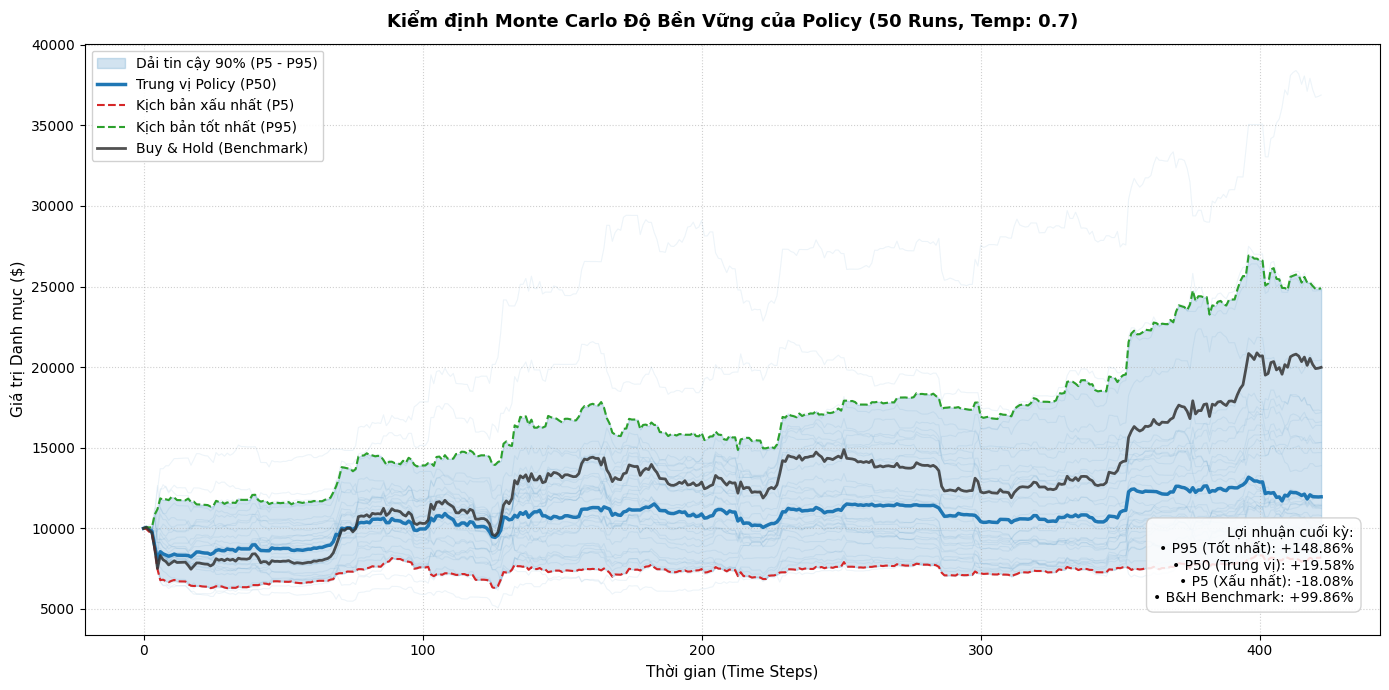

In [11]:
def run_monte_carlo_evaluation(
    test_env,
    model,
    n_simulations: int = 50,
    temperature: float = 0.7,
    initial_capital: float = 10000.0
):
    """
    Thực hiện kiểm định Monte Carlo mô phỏng quá trình ra quyết định ngẫu nhiên của Policy:
      - Thu thập n_simulations đường cong vốn.
      - Trích xuất phân vị P5, P50 (Median), P95 theo từng bước thời gian.
      - Phân tích rủi ro đuôi (Tail Risk) và độ bền vững thống kê so với Buy & Hold.
    """
    model.eval()

    # 1. Trích xuất chuỗi giá và Benchmark (Buy & Hold)
    obs, info = test_env.reset()
    prices = [test_env.df.loc[test_env.current_step, "close"]]
    done = False
    while not done:
        next_obs, _, terminated, truncated, info = test_env.step(0)  # Chạy 1 vòng lấy price
        done = terminated or truncated
        prices.append(info["price"])

    prices = np.array(prices)
    n_steps = len(prices)
    steps = np.arange(n_steps)
    buy_and_hold = initial_capital * (prices / prices[0])

    # Ma trận lưu trữ vốn: shape = (n_simulations, n_steps)
    all_balances = np.zeros((n_simulations, n_steps))
    simulation_metrics = []

    print(f"--- Bắt đầu chạy Monte Carlo ({n_simulations} lần thử nghiệm | Temp: {temperature}) ---")

    for sim in range(n_simulations):
        # Thiết lập seed ngẫu nhiên cho mỗi vòng mô phỏng
        seed = 1000 + sim
        torch.manual_seed(seed)
        np.random.seed(seed)

        obs, info = test_env.reset()
        balances = [info["balance"]]
        done = False

        while not done:
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                feat = model.shared_net(obs_tensor)
                logits = model.actor(feat)
                scaled_logits = logits / max(1e-4, temperature)
                dist = Categorical(logits=scaled_logits)
                action = dist.sample().item()

            obs, _, terminated, truncated, info = test_env.step(action)
            done = terminated or truncated
            balances.append(info["balance"])

        all_balances[sim, :] = np.array(balances[:n_steps])

        # Tính metrics cho lần chạy này
        metrics = calculate_portfolio_metrics(balances[:n_steps])
        simulation_metrics.append(metrics)

        if (sim + 1) % (max(1, n_simulations // 5)) == 0:
            print(f"Hoàn tất mô phỏng: {sim + 1:2d}/{n_simulations}")

    # 2. Tính toán các đường phân vị theo từng bước nến
    p5_curve = np.percentile(all_balances, 5, axis=0)
    p50_curve = np.percentile(all_balances, 50, axis=0)
    p95_curve = np.percentile(all_balances, 95, axis=0)

    # 3. Tổng hợp bảng phân tích thống kê
    df_metrics = pd.DataFrame(simulation_metrics)
    bnh_metrics = calculate_portfolio_metrics(buy_and_hold.tolist())

    summary_stats = {
        "Total Return": {
            "P5 (Worst Case)": df_metrics["Total Return"].quantile(0.05),
            "P50 (Median)": df_metrics["Total Return"].quantile(0.50),
            "P95 (Best Case)": df_metrics["Total Return"].quantile(0.95),
            "Mean": df_metrics["Total Return"].mean(),
            "Std Dev": df_metrics["Total Return"].std(),
            "Buy & Hold": bnh_metrics["Total Return"]
        },
        "Sharpe Ratio": {
            "P5 (Worst Case)": df_metrics["Sharpe Ratio"].quantile(0.05),
            "P50 (Median)": df_metrics["Sharpe Ratio"].quantile(0.50),
            "P95 (Best Case)": df_metrics["Sharpe Ratio"].quantile(0.95),
            "Mean": df_metrics["Sharpe Ratio"].mean(),
            "Std Dev": df_metrics["Sharpe Ratio"].std(),
            "Buy & Hold": bnh_metrics["Sharpe Ratio"]
        },
        "Max Drawdown": {
            "P5 (Worst Case)": df_metrics["Max Drawdown"].quantile(0.05),
            "P50 (Median)": df_metrics["Max Drawdown"].quantile(0.50),
            "P95 (Best Case)": df_metrics["Max Drawdown"].quantile(0.95),
            "Mean": df_metrics["Max Drawdown"].mean(),
            "Std Dev": df_metrics["Max Drawdown"].std(),
            "Buy & Hold": bnh_metrics["Max Drawdown"]
        }
    }

    df_summary = pd.DataFrame(summary_stats).T
    print("\n=== BÁO CÁO PHÂN TÍCH ĐỘ BỀN VỮNG MONTE CARLO (N = 50) ===")
    print(df_summary.map(lambda x: f"{x:.4f}").to_markdown())

    # 4. Trực quan hóa Dải phân vị vốn (Confidence Bands)
    plt.figure(figsize=(14, 7))

    # Vẽ các đường mô phỏng cá lẻ mờ ở nền
    for sim in range(min(30, n_simulations)):
        plt.plot(steps, all_balances[sim, :], color="#1f77b4", alpha=0.08, linewidth=0.8)

    # Tô màu dải tin cậy P5 - P95
    plt.fill_between(steps, p5_curve, p95_curve, color="#1f77b4", alpha=0.2, label="Dải tin cậy 90% (P5 - P95)")

    # Vẽ các đường trọng yếu
    plt.plot(steps, p50_curve, color="#1f77b4", linewidth=2.5, label="Trung vị Policy (P50)")
    plt.plot(steps, p5_curve, color="#d62728", linestyle="--", linewidth=1.5, label="Kịch bản xấu nhất (P5)")
    plt.plot(steps, p95_curve, color="#2ca02c", linestyle="--", linewidth=1.5, label="Kịch bản tốt nhất (P95)")
    plt.plot(steps, buy_and_hold, color="#333333", linestyle="-", linewidth=2.0, alpha=0.85, label="Buy & Hold (Benchmark)")

    plt.title(f"Kiểm định Monte Carlo Độ Bền Vững của Policy ({n_simulations} Runs, Temp: {temperature})", fontsize=13, fontweight="bold", pad=12)
    plt.xlabel("Thời gian (Time Steps)", fontsize=11)
    plt.ylabel("Giá trị Danh mục ($)", fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left", frameon=True, framealpha=0.9)

    # Thống kê nhanh lên góc biểu đồ
    p5_ret = (p5_curve[-1] / initial_capital - 1) * 100
    p50_ret = (p50_curve[-1] / initial_capital - 1) * 100
    p95_ret = (p95_curve[-1] / initial_capital - 1) * 100
    bnh_ret = (buy_and_hold[-1] / initial_capital - 1) * 100

    info_box = (
        f"Lợi nhuận cuối kỳ:\n"
        f"• P95 (Tốt nhất): {p95_ret:+.2f}%\n"
        f"• P50 (Trung vị): {p50_ret:+.2f}%\n"
        f"• P5 (Xấu nhất): {p5_ret:+.2f}%\n"
        f"• B&H Benchmark: {bnh_ret:+.2f}%"
    )
    plt.gca().text(
        0.98, 0.05, info_box, transform=plt.gca().transAxes, fontsize=10,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="#ccc")
    )

    plt.tight_layout()
    plt.show()

    return df_summary, all_balances

# Chạy Monte Carlo 50 lần với test_env có chi phí
summary_df, sim_balances = run_monte_carlo_evaluation(
    test_env=test_env,
    model=trained_a2c,
    n_simulations=50,
    temperature=0.7
)

# Hysteresis / Confidence Gating

In [18]:
# =====================================================================
# H1: QUÁN TÍNH THỜI GIAN (TIME-BASED MINIMUM HOLDING)
# =====================================================================
def eval_h1_time_hold(env, model, temp=0.7, min_hold=3):
    model.eval()
    obs, info = env.reset()
    balances = [info["balance"]]
    positions = [info["position"]]

    current_action = 1
    hold_count = 0
    done = False

    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model.actor(model.shared_net(obs_t))
            dist = torch.distributions.Categorical(logits=logits / max(1e-4, temp))
            sampled = dist.sample().item()

        if sampled != current_action:
            if hold_count >= min_hold:
                current_action = sampled
                hold_count = 0
            else:
                hold_count += 1
        else:
            hold_count += 1

        obs, _, terminated, truncated, info = env.step(current_action)
        done = terminated or truncated
        balances.append(info["balance"])
        positions.append(info["position"])

    metrics = calculate_portfolio_metrics(balances)
    flips = int(np.sum(np.diff(positions) != 0))
    return metrics, flips

# =====================================================================
# H2: TỶ LỆ XÁC SUẤT VƯỢT TRỘI (PROBABILITY RATIO MARGIN)
# =====================================================================
def eval_h2_prob_ratio(env, model, temp=0.7, ratio_threshold=1.5):
    model.eval()
    obs, info = env.reset()
    balances = [info["balance"]]
    positions = [info["position"]]

    current_action = 1
    done = False

    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model.actor(model.shared_net(obs_t))
            probs = F.softmax(logits / max(1e-4, temp), dim=-1).squeeze(0).cpu().numpy()

        candidate = int(np.argmax(probs))
        if candidate != current_action:
            if probs[candidate] >= ratio_threshold * probs[current_action]:
                current_action = candidate

        obs, _, terminated, truncated, info = env.step(current_action)
        done = terminated or truncated
        balances.append(info["balance"])
        positions.append(info["position"])

    metrics = calculate_portfolio_metrics(balances)
    flips = int(np.sum(np.diff(positions) != 0))
    return metrics, flips

# =====================================================================
# H3: LÀM MỊN XÁC SUẤT BẰNG EMA (EXPONENTIAL PROBABILITY SMOOTHING)
# =====================================================================
def eval_h3_ema_probs(env, model, temp=0.7, beta=0.8):
    model.eval()
    obs, info = env.reset()
    balances = [info["balance"]]
    positions = [info["position"]]

    ema_probs = np.array([0.0, 1.0, 0.0])  # Khởi tạo mặc định thiên Long
    done = False

    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model.actor(model.shared_net(obs_t))
            inst_probs = F.softmax(logits / max(1e-4, temp), dim=-1).squeeze(0).cpu().numpy()

        # Làm mịn phân phối qua thời gian
        ema_probs = beta * ema_probs + (1.0 - beta) * inst_probs
        action = int(np.argmax(ema_probs))

        obs, _, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        balances.append(info["balance"])
        positions.append(info["position"])

    metrics = calculate_portfolio_metrics(balances)
    flips = int(np.sum(np.diff(positions) != 0))
    return metrics, flips

# =====================================================================
# H4: LỌC LẤY MẪU NGẪU NHIÊN (STOCHASTIC REJECTION SAMPLING)
# =====================================================================
def eval_h4_stochastic_reject(env, model, temp=0.7, persist_prob=0.6):
    model.eval()
    obs, info = env.reset()
    balances = [info["balance"]]
    positions = [info["position"]]

    current_action = 1
    done = False

    while not done:
        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            logits = model.actor(model.shared_net(obs_t))
            dist = torch.distributions.Categorical(logits=logits / max(1e-4, temp))
            sampled = dist.sample().item()

        if sampled != current_action:
            if np.random.rand() > persist_prob:
                current_action = sampled

        obs, _, terminated, truncated, info = env.step(current_action)
        done = terminated or truncated
        balances.append(info["balance"])
        positions.append(info["position"])

    metrics = calculate_portfolio_metrics(balances)
    flips = int(np.sum(np.diff(positions) != 0))
    return metrics, flips

# =====================================================================
# CHẠY TỔNG HỢP KIỂM TRA ĐA GIẢ THUYẾT (HYPOTHESIS SWEEP)
# =====================================================================
test_configs = [
    # Baseline
    ("Baseline (Raw Sample)", lambda env, m: eval_h4_stochastic_reject(env, m, persist_prob=0.0)),
    # Hypothesis 1: Time Hold
    ("H1: Min Hold 3 Bars",   lambda env, m: eval_h1_time_hold(env, m, min_hold=3)),
    ("H1: Min Hold 5 Bars",   lambda env, m: eval_h1_time_hold(env, m, min_hold=5)),
    # Hypothesis 2: Prob Ratio
    ("H2: Ratio Threshold 1.3", lambda env, m: eval_h2_prob_ratio(env, m, ratio_threshold=1.3)),
    ("H2: Ratio Threshold 1.6", lambda env, m: eval_h2_prob_ratio(env, m, ratio_threshold=1.6)),
    # Hypothesis 3: EMA Smoothing
    ("H3: EMA Smoothing (0.7)", lambda env, m: eval_h3_ema_probs(env, m, beta=0.7)),
    ("H3: EMA Smoothing (0.85)",lambda env, m: eval_h3_ema_probs(env, m, beta=0.85)),
    # Hypothesis 4: Stochastic Reject
    ("H4: Reject Prob 0.5",   lambda env, m: eval_h4_stochastic_reject(env, m, persist_prob=0.5)),
    ("H4: Reject Prob 0.7",   lambda env, m: eval_h4_stochastic_reject(env, m, persist_prob=0.7)),
]

records = []
for name, runner in test_configs:
    np.random.seed(42)
    torch.manual_seed(42)
    m_ppo, flips_ppo = runner(test_env, trained_ppo)

    np.random.seed(42)
    torch.manual_seed(42)
    m_a2c, flips_a2c = runner(test_env, trained_a2c)

    records.append({
        "Mechanism": name, "Model": "PPO",
        "Total Return": m_ppo["Total Return"], "Sharpe": m_ppo["Sharpe Ratio"],
        "Max Drawdown": m_ppo["Max Drawdown"], "Win Rate": m_ppo["Win Rate"],
        "Flips": flips_ppo
    })
    records.append({
        "Mechanism": name, "Model": "A2C",
        "Total Return": m_a2c["Total Return"], "Sharpe": m_a2c["Sharpe Ratio"],
        "Max Drawdown": m_a2c["Max Drawdown"], "Win Rate": m_a2c["Win Rate"],
        "Flips": flips_a2c
    })

df_results = pd.DataFrame(records)
print("\n=== SO SÁNH TOÀN DIỆN CÁC HYPOTHESIS ACTION FILTERING ===")
print(df_results.to_markdown(index=False))


=== SO SÁNH TOÀN DIỆN CÁC HYPOTHESIS ACTION FILTERING ===
| Mechanism                | Model   |   Total Return |     Sharpe |   Max Drawdown |   Win Rate |   Flips |
|:-------------------------|:--------|---------------:|-----------:|---------------:|-----------:|--------:|
| Baseline (Raw Sample)    | PPO     |       0.73377  |  1.46279   |      -0.275395 |   0.368932 |     234 |
| Baseline (Raw Sample)    | A2C     |       0.86067  |  1.25591   |      -0.267006 |   0.431122 |     204 |
| H1: Min Hold 3 Bars      | PPO     |       0.786604 |  1.4341    |      -0.198584 |   0.439394 |      91 |
| H1: Min Hold 3 Bars      | A2C     |       0.426376 |  0.797026  |      -0.271281 |   0.441358 |      85 |
| H1: Min Hold 5 Bars      | PPO     |      -0.131029 | -0.0931498 |      -0.268843 |   0.496377 |      63 |
| H1: Min Hold 5 Bars      | A2C     |      -0.109264 | -0.0465537 |      -0.42446  |   0.515823 |      65 |
| H2: Ratio Threshold 1.3  | PPO     |       0        |  0         | 

## testing with hypo. result

--- Bắt đầu Monte Carlo H4 (A2C | 50 Runs | Reject Prob: 0.5) ---
Hoàn tất: 10/50
Hoàn tất: 20/50
Hoàn tất: 30/50
Hoàn tất: 40/50
Hoàn tất: 50/50

=== BÁO CÁO MONTE CARLO H4 (A2C | N = 50) ===
|              |   P5 (Worst) |   P50 (Median) |   P95 (Best) |    Mean |   Std Dev |   Buy & Hold |
|:-------------|-------------:|---------------:|-------------:|--------:|----------:|-------------:|
| Total Return |      -0.3642 |         0.3595 |       1.2004 |  0.4108 |    0.5783 |       0.9986 |
| Sharpe Ratio |      -0.5823 |         0.7136 |       1.5792 |  0.642  |    0.7304 |       1.2649 |
| Max Drawdown |      -0.4764 |        -0.3107 |      -0.1902 | -0.3248 |    0.0931 |      -0.2582 |
| Win Rate     |       0.4014 |         0.437  |       0.4642 |  0.4348 |    0.0215 |       0.4882 |
Số lần đổi vị thế trung bình (Mean Flips): 111.8 ± 10.4


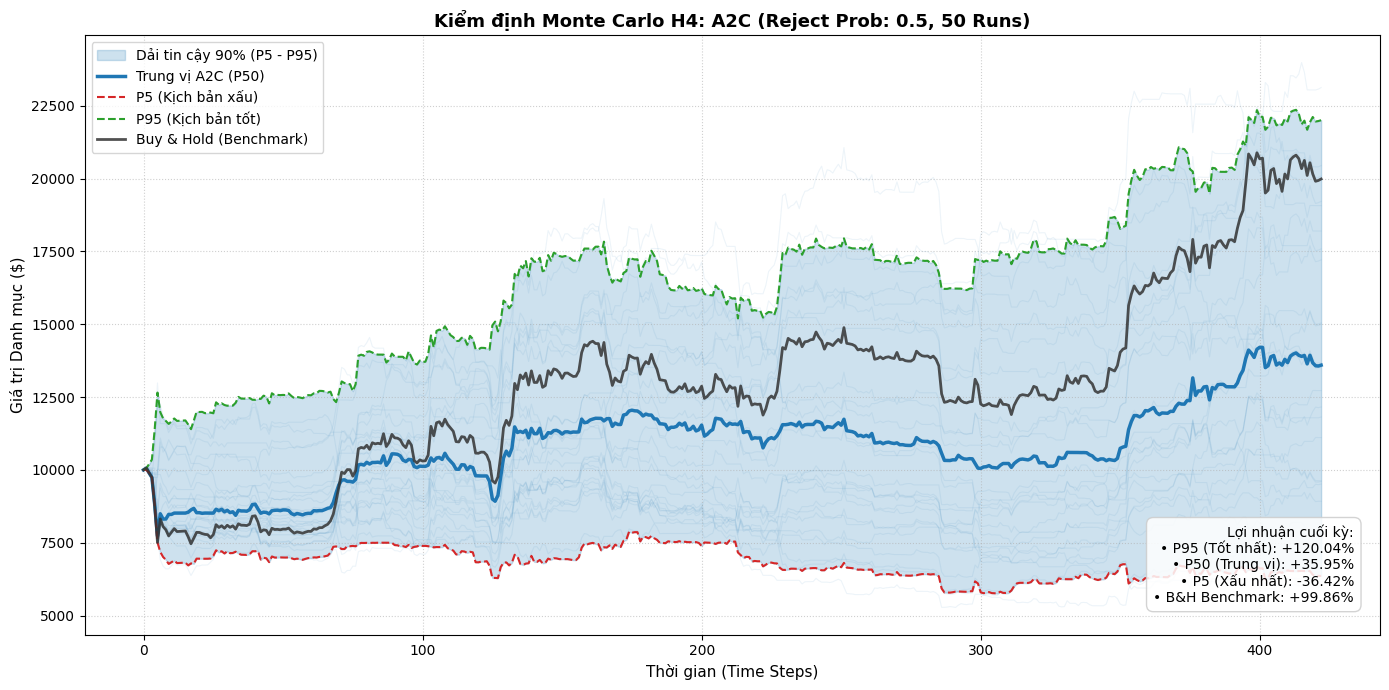

--- Bắt đầu Monte Carlo H4 (PPO | 50 Runs | Reject Prob: 0.5) ---
Hoàn tất: 10/50
Hoàn tất: 20/50
Hoàn tất: 30/50
Hoàn tất: 40/50
Hoàn tất: 50/50

=== BÁO CÁO MONTE CARLO H4 (PPO | N = 50) ===
|              |   P5 (Worst) |   P50 (Median) |   P95 (Best) |    Mean |   Std Dev |   Buy & Hold |
|:-------------|-------------:|---------------:|-------------:|--------:|----------:|-------------:|
| Total Return |      -0.412  |         0.1424 |       1.1981 |  0.1949 |    0.5011 |       0.9986 |
| Sharpe Ratio |      -0.9771 |         0.4484 |       1.7818 |  0.3628 |    0.8808 |       1.2649 |
| Max Drawdown |      -0.4931 |        -0.271  |      -0.1321 | -0.2966 |    0.1117 |      -0.2582 |
| Win Rate     |       0.3273 |         0.378  |       0.4239 |  0.3812 |    0.0302 |       0.4882 |
Số lần đổi vị thế trung bình (Mean Flips): 121.3 ± 10.7


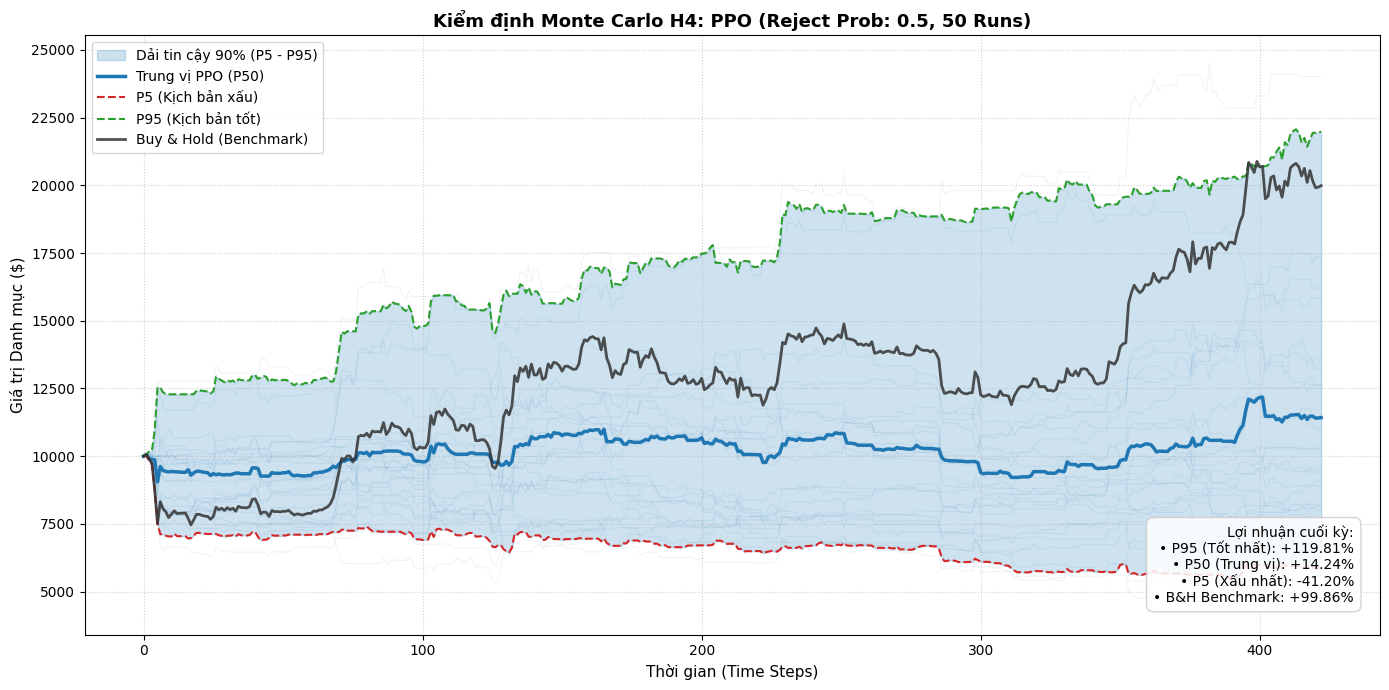

In [19]:
def run_monte_carlo_h4(
    test_env,
    model,
    model_name: str = "A2C",
    n_simulations: int = 50,
    temp: float = 0.7,
    persist_prob: float = 0.5,
    initial_capital: float = 10000.0
):
    model.eval()

    # 1. Trích xuất benchmark Buy & Hold
    start_idx = test_env.window_size
    prices = test_env.df.loc[start_idx:, "close"].values
    n_steps = len(prices)
    steps = np.arange(n_steps)
    buy_and_hold = initial_capital * (prices / prices[0])

    all_balances = np.zeros((n_simulations, n_steps))
    simulation_metrics = []
    flips_list = []

    print(f"--- Bắt đầu Monte Carlo H4 ({model_name} | {n_simulations} Runs | Reject Prob: {persist_prob}) ---")

    for sim in range(n_simulations):
        seed = 2000 + sim
        torch.manual_seed(seed)
        np.random.seed(seed)

        obs, info = test_env.reset()
        balances = [info["balance"]]
        positions = [info["position"]]
        current_action = 1  # Bắt đầu Long
        done = False

        while not done:
            obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                feat = model.shared_net(obs_t)
                logits = model.actor(feat)
                dist = torch.distributions.Categorical(logits=logits / max(1e-4, temp))
                sampled_action = dist.sample().item()

            # Cơ chế H4: Lọc lấy mẫu bằng xác suất từ chối đổi lệnh
            if sampled_action != current_action:
                if np.random.rand() > persist_prob:
                    current_action = sampled_action

            obs, _, terminated, truncated, info = test_env.step(current_action)
            done = terminated or truncated
            balances.append(info["balance"])
            positions.append(info["position"])

        current_balances = np.array(balances[:n_steps])
        all_balances[sim, :] = current_balances
        simulation_metrics.append(calculate_portfolio_metrics(current_balances.tolist()))
        flips_list.append(int(np.sum(np.diff(positions[:n_steps]) != 0)))

        if (sim + 1) % (max(1, n_simulations // 5)) == 0:
            print(f"Hoàn tất: {sim + 1:2d}/{n_simulations}")

    # 2. Tính toán phân vị
    p5_curve = np.percentile(all_balances, 5, axis=0)
    p50_curve = np.percentile(all_balances, 50, axis=0)
    p95_curve = np.percentile(all_balances, 95, axis=0)

    # 3. Tổng hợp số liệu thống kê
    df_m = pd.DataFrame(simulation_metrics)
    bnh_m = calculate_portfolio_metrics(buy_and_hold.tolist())

    summary = {
        "Total Return": {
            "P5 (Worst)": df_m["Total Return"].quantile(0.05),
            "P50 (Median)": df_m["Total Return"].quantile(0.50),
            "P95 (Best)": df_m["Total Return"].quantile(0.95),
            "Mean": df_m["Total Return"].mean(),
            "Std Dev": df_m["Total Return"].std(),
            "Buy & Hold": bnh_m["Total Return"]
        },
        "Sharpe Ratio": {
            "P5 (Worst)": df_m["Sharpe Ratio"].quantile(0.05),
            "P50 (Median)": df_m["Sharpe Ratio"].quantile(0.50),
            "P95 (Best)": df_m["Sharpe Ratio"].quantile(0.95),
            "Mean": df_m["Sharpe Ratio"].mean(),
            "Std Dev": df_m["Sharpe Ratio"].std(),
            "Buy & Hold": bnh_m["Sharpe Ratio"]
        },
        "Max Drawdown": {
            "P5 (Worst)": df_m["Max Drawdown"].quantile(0.05),
            "P50 (Median)": df_m["Max Drawdown"].quantile(0.50),
            "P95 (Best)": df_m["Max Drawdown"].quantile(0.95),
            "Mean": df_m["Max Drawdown"].mean(),
            "Std Dev": df_m["Max Drawdown"].std(),
            "Buy & Hold": bnh_m["Max Drawdown"]
        },
        "Win Rate": {
            "P5 (Worst)": df_m["Win Rate"].quantile(0.05),
            "P50 (Median)": df_m["Win Rate"].quantile(0.50),
            "P95 (Best)": df_m["Win Rate"].quantile(0.95),
            "Mean": df_m["Win Rate"].mean(),
            "Std Dev": df_m["Win Rate"].std(),
            "Buy & Hold": bnh_m["Win Rate"]
        }
    }
    df_summary = pd.DataFrame(summary).T
    print(f"\n=== BÁO CÁO MONTE CARLO H4 ({model_name} | N = {n_simulations}) ===")
    print(df_summary.map(lambda x: f"{x:.4f}").to_markdown())
    print(f"Số lần đổi vị thế trung bình (Mean Flips): {np.mean(flips_list):.1f} ± {np.std(flips_list):.1f}")

    # 4. Vẽ đồ thị dải tin cậy
    plt.figure(figsize=(14, 7))
    for sim in range(min(25, n_simulations)):
        plt.plot(steps, all_balances[sim, :], color="#1f77b4", alpha=0.08, linewidth=0.8)

    plt.fill_between(steps, p5_curve, p95_curve, color="#1f77b4", alpha=0.22, label=f"Dải tin cậy 90% (P5 - P95)")
    plt.plot(steps, p50_curve, color="#1f77b4", linewidth=2.5, label=f"Trung vị {model_name} (P50)")
    plt.plot(steps, p5_curve, color="#d62728", linestyle="--", linewidth=1.5, label="P5 (Kịch bản xấu)")
    plt.plot(steps, p95_curve, color="#2ca02c", linestyle="--", linewidth=1.5, label="P95 (Kịch bản tốt)")
    plt.plot(steps, buy_and_hold, color="#333333", linestyle="-", linewidth=2.0, alpha=0.85, label="Buy & Hold (Benchmark)")

    plt.title(f"Kiểm định Monte Carlo H4: {model_name} (Reject Prob: {persist_prob}, {n_simulations} Runs)", fontsize=13, fontweight="bold")
    plt.xlabel("Thời gian (Time Steps)", fontsize=11)
    plt.ylabel("Giá trị Danh mục ($)", fontsize=11)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend(loc="upper left")

    p5_ret = (p5_curve[-1] / initial_capital - 1) * 100
    p50_ret = (p50_curve[-1] / initial_capital - 1) * 100
    p95_ret = (p95_curve[-1] / initial_capital - 1) * 100
    bnh_ret = (buy_and_hold[-1] / initial_capital - 1) * 100

    info_box = (
        f"Lợi nhuận cuối kỳ:\n"
        f"• P95 (Tốt nhất): {p95_ret:+.2f}%\n"
        f"• P50 (Trung vị): {p50_ret:+.2f}%\n"
        f"• P5 (Xấu nhất): {p5_ret:+.2f}%\n"
        f"• B&H Benchmark: {bnh_ret:+.2f}%"
    )
    plt.gca().text(
        0.98, 0.05, info_box, transform=plt.gca().transAxes, fontsize=10,
        verticalalignment="bottom", horizontalalignment="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.85, edgecolor="#ccc")
    )

    plt.tight_layout()
    plt.show()

    return df_summary, all_balances

# Kiểm định Monte Carlo cho A2C với cơ chế H4 (Reject Prob = 0.5)
summary_a2c_h4, balances_a2c_h4 = run_monte_carlo_h4(
    test_env=test_env,
    model=trained_a2c,
    model_name="A2C",
    n_simulations=50,
    temp=0.7,
    persist_prob=0.5
)

# Kiểm định Monte Carlo cho PPO với cơ chế H4 (Reject Prob = 0.5)
summary_ppo_h4, balances_ppo_h4 = run_monte_carlo_h4(
    test_env=test_env,
    model=trained_ppo,
    model_name="PPO",
    n_simulations=50,
    temp=0.7,
    persist_prob=0.5
)

# Archival & Handover: Meta-Labeling Phase

All empirical outputs, performance metrics, and feature selection artifacts for the meta-labeling framework have been successfully structured and prepared for final archiving.

In [21]:
def generate_meta_labeling_dataset(
    env,
    model,
    raw_df: pd.DataFrame,
    temperature: float = 0.7,
    persist_prob: float = 0.5,
    seed: int = 42,
) -> pd.DataFrame:
    """Chạy suy luận mô hình với bộ lọc H4 và trích xuất toàn bộ trajectory để làm đầu vào

    cho Meta-Labeling Pipeline (Triple-Barrier Method).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)
    model.eval()

    obs, info = env.reset()

    # Danh sách lưu trữ trajectory
    step_indices = []
    prices = []
    raw_sampled_actions = []
    executed_positions = []
    prob_cash_list = []
    prob_long_list = []
    prob_short_list = []
    actor_confidences = []

    current_action = 1  # Khởi đầu vị thế Long
    done = False

    while not done:
        curr_step = env.current_step
        current_price = env.df.loc[curr_step, "close"]

        obs_t = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            feat = model.shared_net(obs_t)
            logits = model.actor(feat)
            probs = (
                F.softmax(logits / max(1e-4, temperature), dim=-1)
                .squeeze(0)
                .cpu()
                .numpy()
            )

            dist = torch.distributions.Categorical(probs=torch.tensor(probs))
            sampled_action = dist.sample().item()

        # Cơ chế H4: Lọc lấy mẫu bằng xác suất từ chối đổi lệnh
        if sampled_action != current_action:
            if np.random.rand() > persist_prob:
                current_action = sampled_action

        # Thực hiện bước môi trường (Env tự áp dụng Trend-Shield bên trong step)
        obs, _, terminated, truncated, info = env.step(current_action)
        done = terminated or truncated

        # Lưu lại thông số tại bước này
        step_indices.append(curr_step)
        prices.append(current_price)
        raw_sampled_actions.append(sampled_action)
        executed_positions.append(
            info["position"]
        )  # -1 (Short), 0 (Cash), 1 (Long)
        prob_cash_list.append(probs[0])
        prob_long_list.append(probs[1])
        prob_short_list.append(probs[2])
        actor_confidences.append(np.max(probs))

    # Ánh xạ index thời gian gốc từ DataFrame thị trường
    timestamps = raw_df.index[step_indices]

    # Đóng gói DataFrame chuẩn hóa bàn giao cho Meta-Labeling
    signals_df = pd.DataFrame(
        {
            "timestamp": timestamps,
            "close": prices,
            "rl_raw_action": raw_sampled_actions,  # 0: Cash, 1: Long, 2: Short (kết quả sample)
            "rl_position": executed_positions,  # Vị thế thực tế (-1, 0, 1) sau Trend-Shield & H4
            "rl_prob_cash": prob_cash_list,  # Xác suất Actor chọn Cash
            "rl_prob_long": prob_long_list,  # Xác suất Actor chọn Long
            "rl_prob_short": prob_short_list,  # Xác suất Actor chọn Short
            "rl_confidence": actor_confidences,  # max(P(a)) - độ tự tin cao nhất của Actor
        }
    ).set_index("timestamp")

    # Xác định các điểm phát tín hiệu thay đổi vị thế (Events / Triggers cho Triple-Barrier)
    signals_df["position_changed"] = (
        signals_df["rl_position"].diff().fillna(0) != 0
    ).astype(int)

    return signals_df

# Trích xuất dữ liệu tín hiệu từ mô hình A2C (hoặc trained_ppo)
primary_signals_df = generate_meta_labeling_dataset(
    env=test_env,
    model=trained_a2c,
    raw_df=test_df,
    temperature=0.7,
    persist_prob=0.5,
    seed=42
)

# Hiển thị 5 dòng đầu tiên
print("=== CẤU TRÚC DỮ LIỆU ĐÃ ĐÓNG GÓI CHO META-LABELING ===")
print(primary_signals_df.head().to_markdown())

# Thống kê nhanh các sự kiện đổi vị thế
total_bars = len(primary_signals_df)
total_triggers = primary_signals_df["position_changed"].sum()
print(f"\nTổng số bước nến: {total_bars}")
print(f"Tổng số sự kiện đổi lệnh cần Meta-Model xác nhận (Triggers): {total_triggers}")

=== CẤU TRÚC DỮ LIỆU ĐÃ ĐÓNG GÓI CHO META-LABELING ===
|   timestamp |   close |   rl_raw_action |   rl_position |   rl_prob_cash |   rl_prob_long |   rl_prob_short |   rl_confidence |   position_changed |
|------------:|--------:|----------------:|--------------:|---------------:|---------------:|----------------:|----------------:|-------------------:|
|          10 | 21147.2 |               1 |             1 |       0.248848 |       0.632177 |        0.118975 |        0.632177 |                  0 |
|          11 | 21282.7 |               0 |             1 |       0.248848 |       0.632177 |        0.118975 |        0.632177 |                  0 |
|          12 | 20926.5 |               2 |            -1 |       0.248848 |       0.632177 |        0.118975 |        0.632177 |                  1 |
|          13 | 20602.8 |               1 |             1 |       0.248848 |       0.632177 |        0.118975 |        0.632177 |                  1 |
|          14 | 18541.3 |              